In [28]:
import os, zipfile, torch, torch.nn as nn, torch.optim as optim
import numpy as np, matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from tqdm.notebook import tqdm
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Use the Absolute Paths discovered by the search script
train_path = '/workspace/Agentic_AI/dataset/dataset/train'
val_path = '/workspace/Agentic_AI/dataset/dataset/val'

class LensingDataset(Dataset):
    """
    Custom Dataset for .npy lensing simulations.
    Standardizes input to (1, H, W) for physics-informed processing.
    """
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = ['no', 'sphere', 'vort']
        self.files = []
        
        if not os.path.exists(root_dir):
            raise FileNotFoundError(f"Directory not found: {root_dir}")

        for i, c in enumerate(self.classes):
            p = os.path.join(root_dir, c)
            if os.path.exists(p):
                file_list = [f for f in os.listdir(p) if f.endswith('.npy')]
                for f in file_list:
                    self.files.append((os.path.join(p, f), i))
                print(f"Loaded {len(file_list)} samples for class: {c}")
            else:
                print(f"Warning: Folder for class '{c}' not found at {p}")

    def __len__(self): 
        return len(self.files)

    def __getitem__(self, idx):
        path, label = self.files[idx]
        img = np.load(path).astype(np.float32)
        
        # Standardize to 2D (H, W) before adding channel dim
        if img.ndim == 3: 
            img = np.squeeze(img)
            
        # Physics models often expect 1-channel intensity maps (1, H, W)
        img_tensor = torch.from_numpy(img).unsqueeze(0)
        
        if self.transform:
            img_tensor = self.transform(img_tensor)
            
        return img_tensor, label

# Initialize the datasets
train_dataset = LensingDataset(train_path)
val_dataset = LensingDataset(val_path)

# Initialize the loaders
# Ensure batch size is consistent with your GPU memory (32 is a safe default)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"\nTotal training samples: {len(train_dataset)}")
print(f"Total validation samples: {len(val_dataset)}")

Loaded 10000 samples for class: no
Loaded 10000 samples for class: sphere
Loaded 10000 samples for class: vort
Loaded 2500 samples for class: no
Loaded 2500 samples for class: sphere
Loaded 2500 samples for class: vort

Total training samples: 30000
Total validation samples: 7500


In [23]:
class SISLensLayer(nn.Module):
    def __init__(self, img_size=150):
        super().__init__()
        self.img_size = img_size
        # Making the x-y grid 150x150 now
        x = torch.linspace(-1, 1, img_size)
        y = torch.linspace(-1, 1, img_size)
        grid_y, grid_x = torch.meshgrid(y, x, indexing='ij')
        self.register_buffer('grid_x', grid_x)
        self.register_buffer('grid_y', grid_y)

    def forward(self, params):
        theta_e = params[:, 0:1, None, None]
        cx = (params[:, 1:2, None, None] - 0.5) * 0.4 
        cy = (params[:, 2:3, None, None] - 0.5) * 0.4
        
        r = torch.sqrt((self.grid_x - cx)**2 + (self.grid_y - cy)**2 + 1e-8)
        smooth_model = torch.exp(-((r - theta_e)**2) / 0.02)
        return smooth_model

In [24]:
class PhysicsInformedLensNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.phys_branch = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.phys_branch.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.phys_branch.fc = nn.Linear(512, 3) 
        
        self.physics_layer = SISLensLayer(img_size=150)
        
        self.classifier = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.classifier.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.classifier.fc = nn.Linear(512, 3)

    def forward(self, x):
        phys_params = torch.sigmoid(self.phys_branch(x)) 
        smooth_model = self.physics_layer(phys_params)
        
        residual = x - smooth_model
        
        return self.classifier(residual)

model = PhysicsInformedLensNet().to(device)

In [26]:
# Training the model
optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

epochs = 10
for epoch in range(epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
    
    for imgs, labels in pbar:
        imgs, labels = imgs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, pred = outputs.max(1)
        total += labels.size(0)
        correct += pred.eq(labels).sum().item()
        
        pbar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{100.*correct/total:.2f}%")

    print(f"Epoch {epoch+1} finished. Avg Loss: {running_loss/len(train_loader):.4f}")

Epoch 1/15:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 1 finished. Avg Loss: 1.1169


Epoch 2/15:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 2 finished. Avg Loss: 0.8433


Epoch 3/15:   0%|          | 0/938 [00:00<?, ?it/s]

...

Epoch 13 finished. Avg Loss: 0.1346


Epoch 14/15:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 14 finished. Avg Loss: 0.1001


Epoch 15/15:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 15 finished. Avg Loss: 0.0822


Evaluating PINN:   0%|          | 0/235 [00:00<?, ?it/s]

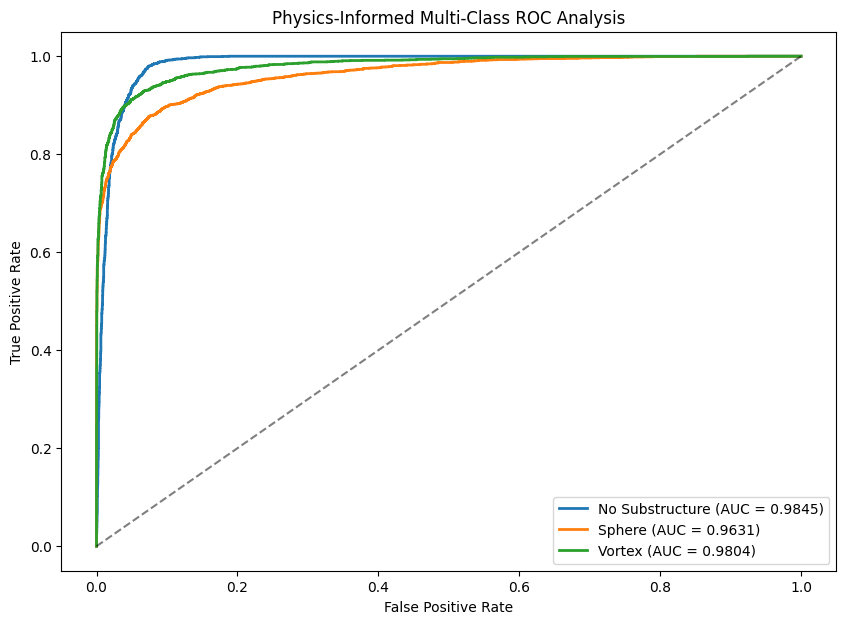

Final PINN Macro-Average AUC: 0.9760


In [29]:
#ROC Curve Evaluation
model.eval()
all_probs, all_labels = [], []

with torch.no_grad():
    for imgs, labels in tqdm(val_loader, desc="Evaluating PINN"):
        outputs = model(imgs.to(device))
        probs = torch.softmax(outputs, dim=1)
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

all_probs = np.array(all_probs)
all_labels_bin = label_binarize(all_labels, classes=[0, 1, 2])

plt.figure(figsize=(10, 7))
for i, name in enumerate(['No Substructure', 'Sphere', 'Vortex']):
    fpr, tpr, _ = roc_curve(all_labels_bin[:, i], all_probs[:, i])
    score = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {score:.4f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Physics-Informed Multi-Class ROC Analysis')
plt.legend(loc="lower right")
plt.show()

macro_auc = roc_auc_score(all_labels_bin, all_probs, average='macro', multi_class='ovr')
print(f"Final PINN Macro-Average AUC: {macro_auc:.4f}")

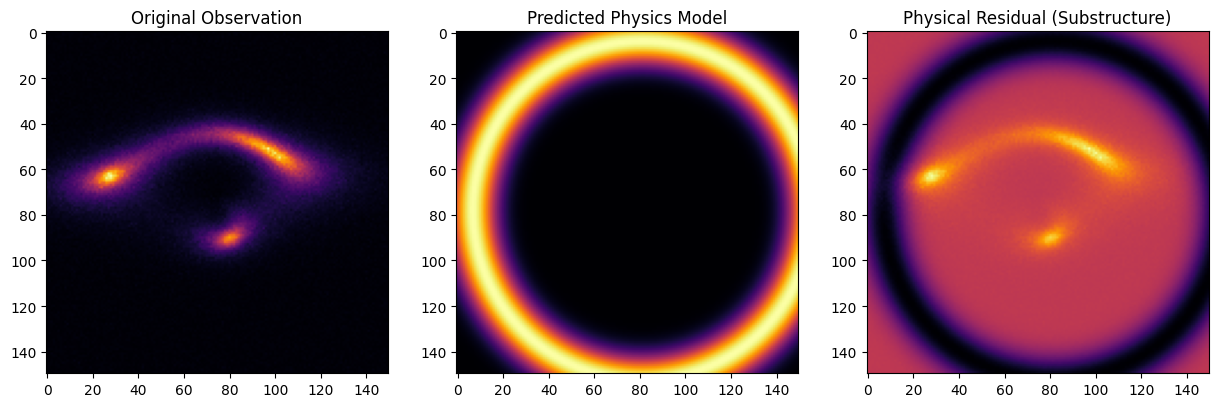

In [30]:
# Physics Visualization
model.eval()
sample_img, _ = val_dataset[0]
sample_img = sample_img.unsqueeze(0).to(device)

with torch.no_grad():
    # Capture intermediate outputs
    params = torch.sigmoid(model.phys_branch(sample_img))
    smooth = model.physics_layer(params)
    residual = sample_img - smooth

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(sample_img.cpu().squeeze(), cmap='inferno')
ax[0].set_title("Original Observation")
ax[1].imshow(smooth.cpu().squeeze(), cmap='inferno')
ax[1].set_title("Predicted Physics Model")
ax[2].imshow(residual.cpu().squeeze(), cmap='inferno')
ax[2].set_title("Physical Residual (Substructure)")
plt.show()